# Laboratorio 3

## Reconocimiento de lenguaje de señas ASL

### Avance

Análisis exploratorio, preprocesamiento, selección de modelos y plan para procesamiento de imágenes

## Objetivo

El objetivo del proyecto es crear un clasificador de imágenes que reconozca letras del alfabeto ASL.

En este avance se estudia el dataset, se prepara una división de datos y se define el plan para entrenar los modelos.

## Descripción del dataset

El dataset contiene fotografías reales de manos.

Las imágenes están organizadas en carpetas según su clase.

Se espera encontrar 29 clases.

Las clases incluyen las letras de la A a la Z y las clases del, nothing y space.

El conjunto oficial de prueba contiene pocas imágenes. Por esta razón se creará un conjunto propio de entrenamiento, validación y prueba.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image as NotebookImage
from IPython.display import display

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Carpeta del proyecto:", project_root)

Carpeta del proyecto: c:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science


## Preguntas del análisis exploratorio

1. Cuántas clases contiene el dataset

2. Cuántas imágenes tiene cada clase

3. El dataset está balanceado

4. Qué formato y resolución tienen las imágenes

5. Existe variabilidad dentro de una misma clase

6. Qué clases se parecen visualmente

7. Existen imágenes que no se pueden abrir

In [2]:
from src.exploratory_analysis import run_exploratory_analysis

eda_summary = run_exploratory_analysis(
    sample_per_class=50,
    full_validation=False,
)

eda_summary

El análisis exploratorio terminó.
Clases encontradas: 29
Imágenes encontradas: 87000
Resumen guardado en: C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\reports\exploratory_summary.json


{'train_directory': 'C:\\Users\\ninan\\OneDrive\\Documentos\\Escritorio\\UVG\\VIII SEMESTRE\\Data Science\\Data_Science\\data\\raw\\asl_alphabet_train\\asl_alphabet_train',
 'number_of_classes': 29,
 'class_names': ['A',
  'B',
  'C',
  'D',
  'E',
  'F',
  'G',
  'H',
  'I',
  'J',
  'K',
  'L',
  'M',
  'N',
  'O',
  'P',
  'Q',
  'R',
  'S',
  'T',
  'U',
  'V',
  'W',
  'X',
  'Y',
  'Z',
  'del',
  'nothing',
  'space'],
 'total_images': 87000,
 'minimum_images_per_class': 3000,
 'maximum_images_per_class': 3000,
 'balance_ratio': 1.0,
 'most_common_classes': [{'class_name': 'A', 'image_count': 3000},
  {'class_name': 'B', 'image_count': 3000},
  {'class_name': 'C', 'image_count': 3000}],
 'least_common_classes': [{'class_name': 'A', 'image_count': 3000},
  {'class_name': 'B', 'image_count': 3000},
  {'class_name': 'C', 'image_count': 3000}],
 'inspected_images': 1450,
 'full_validation': False,
 'damaged_images_found': 0,
 'damaged_files': [],
 'resolutions': {'200x200': 1450},
 

## Resumen general

La siguiente celda muestra los resultados principales encontrados por el script.

La revisión de propiedades usa una muestra de imágenes por clase para reducir el tiempo de ejecución.

La validación completa se puede ejecutar después con la opción full validation.

In [3]:
summary_table = pd.DataFrame(
    {
        "Dato": [
            "Cantidad de clases",
            "Cantidad total de imágenes",
            "Mínimo por clase",
            "Máximo por clase",
            "Relación de balance",
            "Imágenes revisadas",
            "Imágenes dañadas encontradas",
            "Imágenes del test oficial",
        ],
        "Resultado": [
            eda_summary["number_of_classes"],
            eda_summary["total_images"],
            eda_summary["minimum_images_per_class"],
            eda_summary["maximum_images_per_class"],
            eda_summary["balance_ratio"],
            eda_summary["inspected_images"],
            eda_summary["damaged_images_found"],
            eda_summary["official_test_images"],
        ],
    }
)

display(summary_table)

,Dato,Resultado
0,Cantidad de clases,29.0
1,Cantidad total de imágenes,87000.0
2,Mínimo por clase,3000.0
3,Máximo por clase,3000.0
4,Relación de balance,1.0
5,Imágenes revisadas,1450.0
6,Imágenes dañadas encontradas,0.0
7,Imágenes del test oficial,28.0


## Distribución de clases

La distribución permite revisar si todas las clases tienen una cantidad parecida de imágenes.

Un valor de balance cercano a 1 indica que la clase con menos imágenes y la clase con más imágenes tienen tamaños parecidos.

,class_name,image_count
0,A,3000
1,B,3000
2,C,3000
3,D,3000
4,E,3000
5,F,3000
6,G,3000
7,H,3000
8,I,3000
9,J,3000


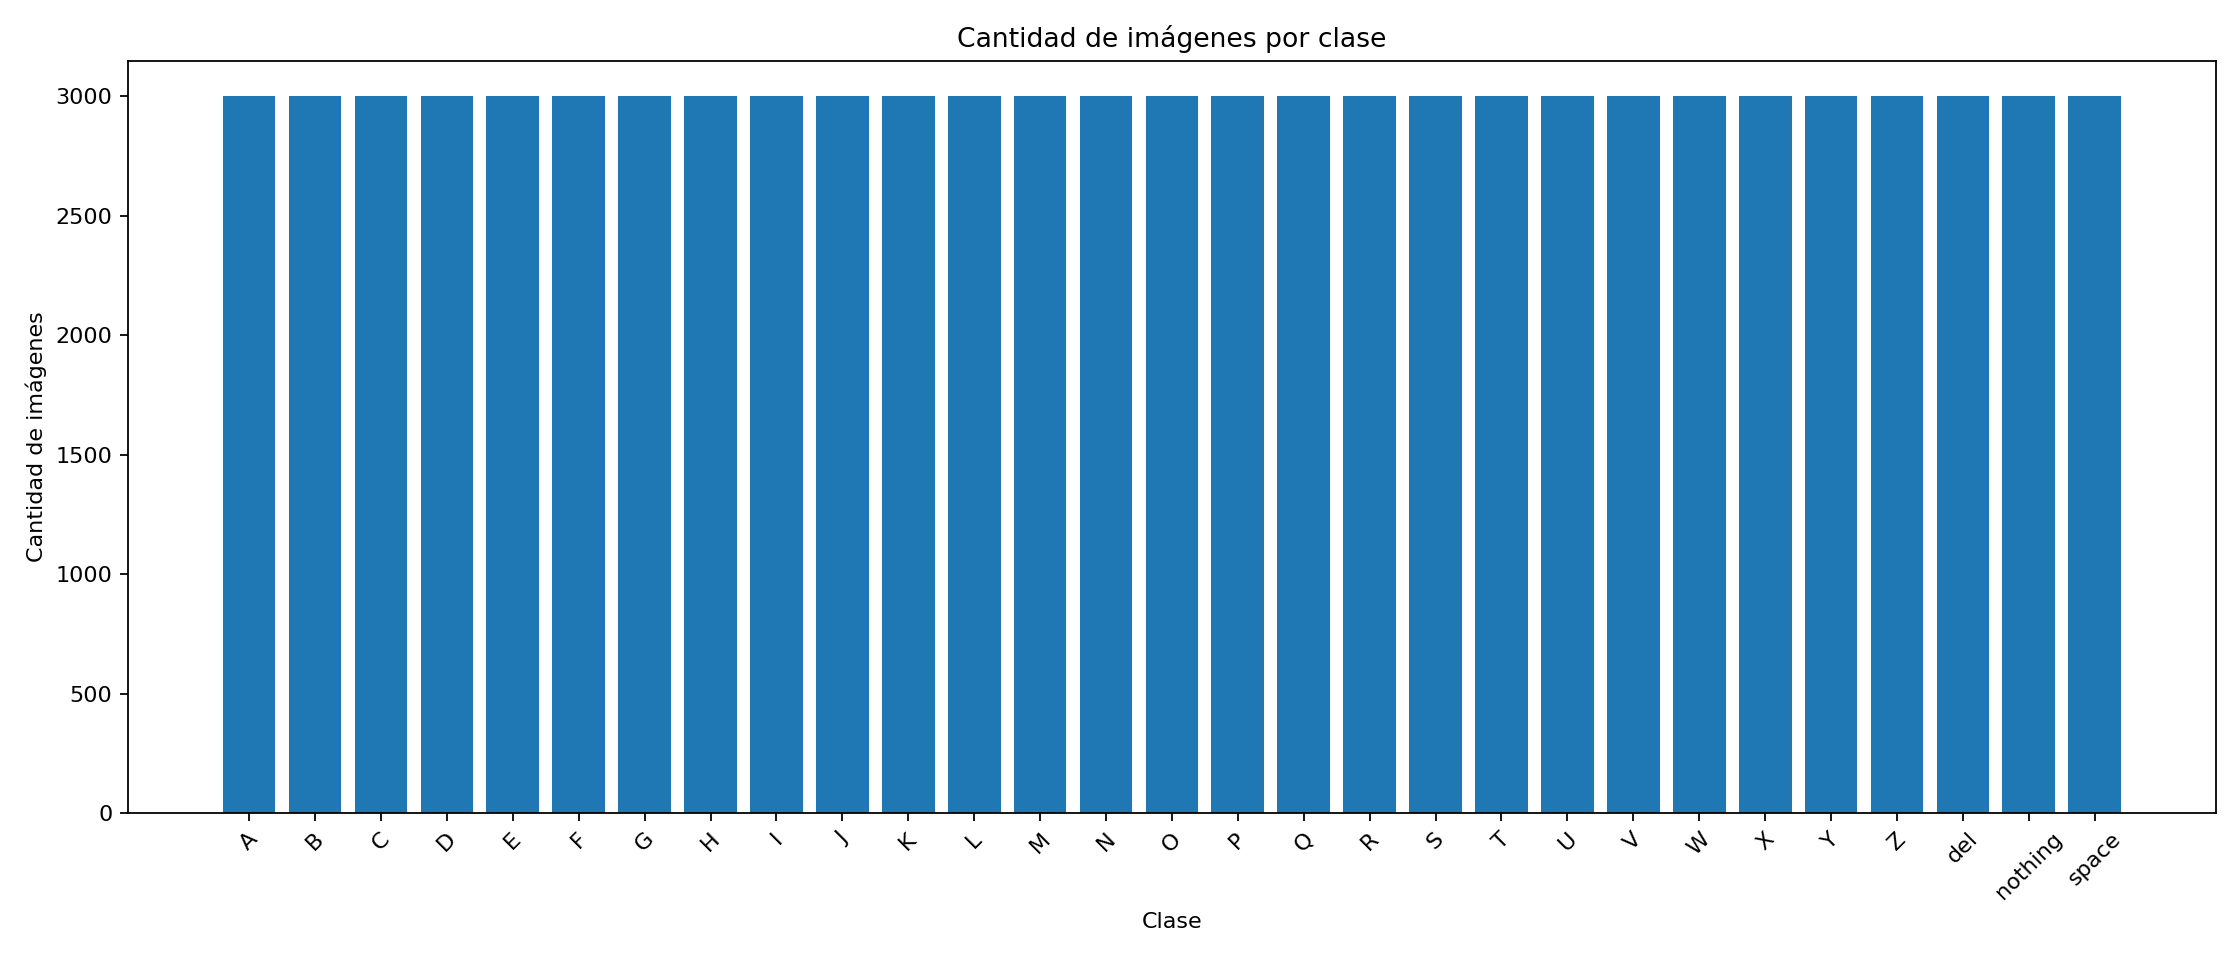

In [4]:
distribution_path = project_root / "data" / "processed" / "reports" / "class_distribution.csv"
distribution = pd.read_csv(distribution_path)

display(distribution)
display(
    NotebookImage(
        filename=str(
            project_root
            / "data"
            / "processed"
            / "figures"
            / "class_distribution.png"
        )
    )
)

## Ejemplos de clases

La figura muestra cinco clases distintas.

Se incluyen varias imágenes por clase para observar que una misma seña puede cambiar por la posición, la distancia, la iluminación y el fondo.

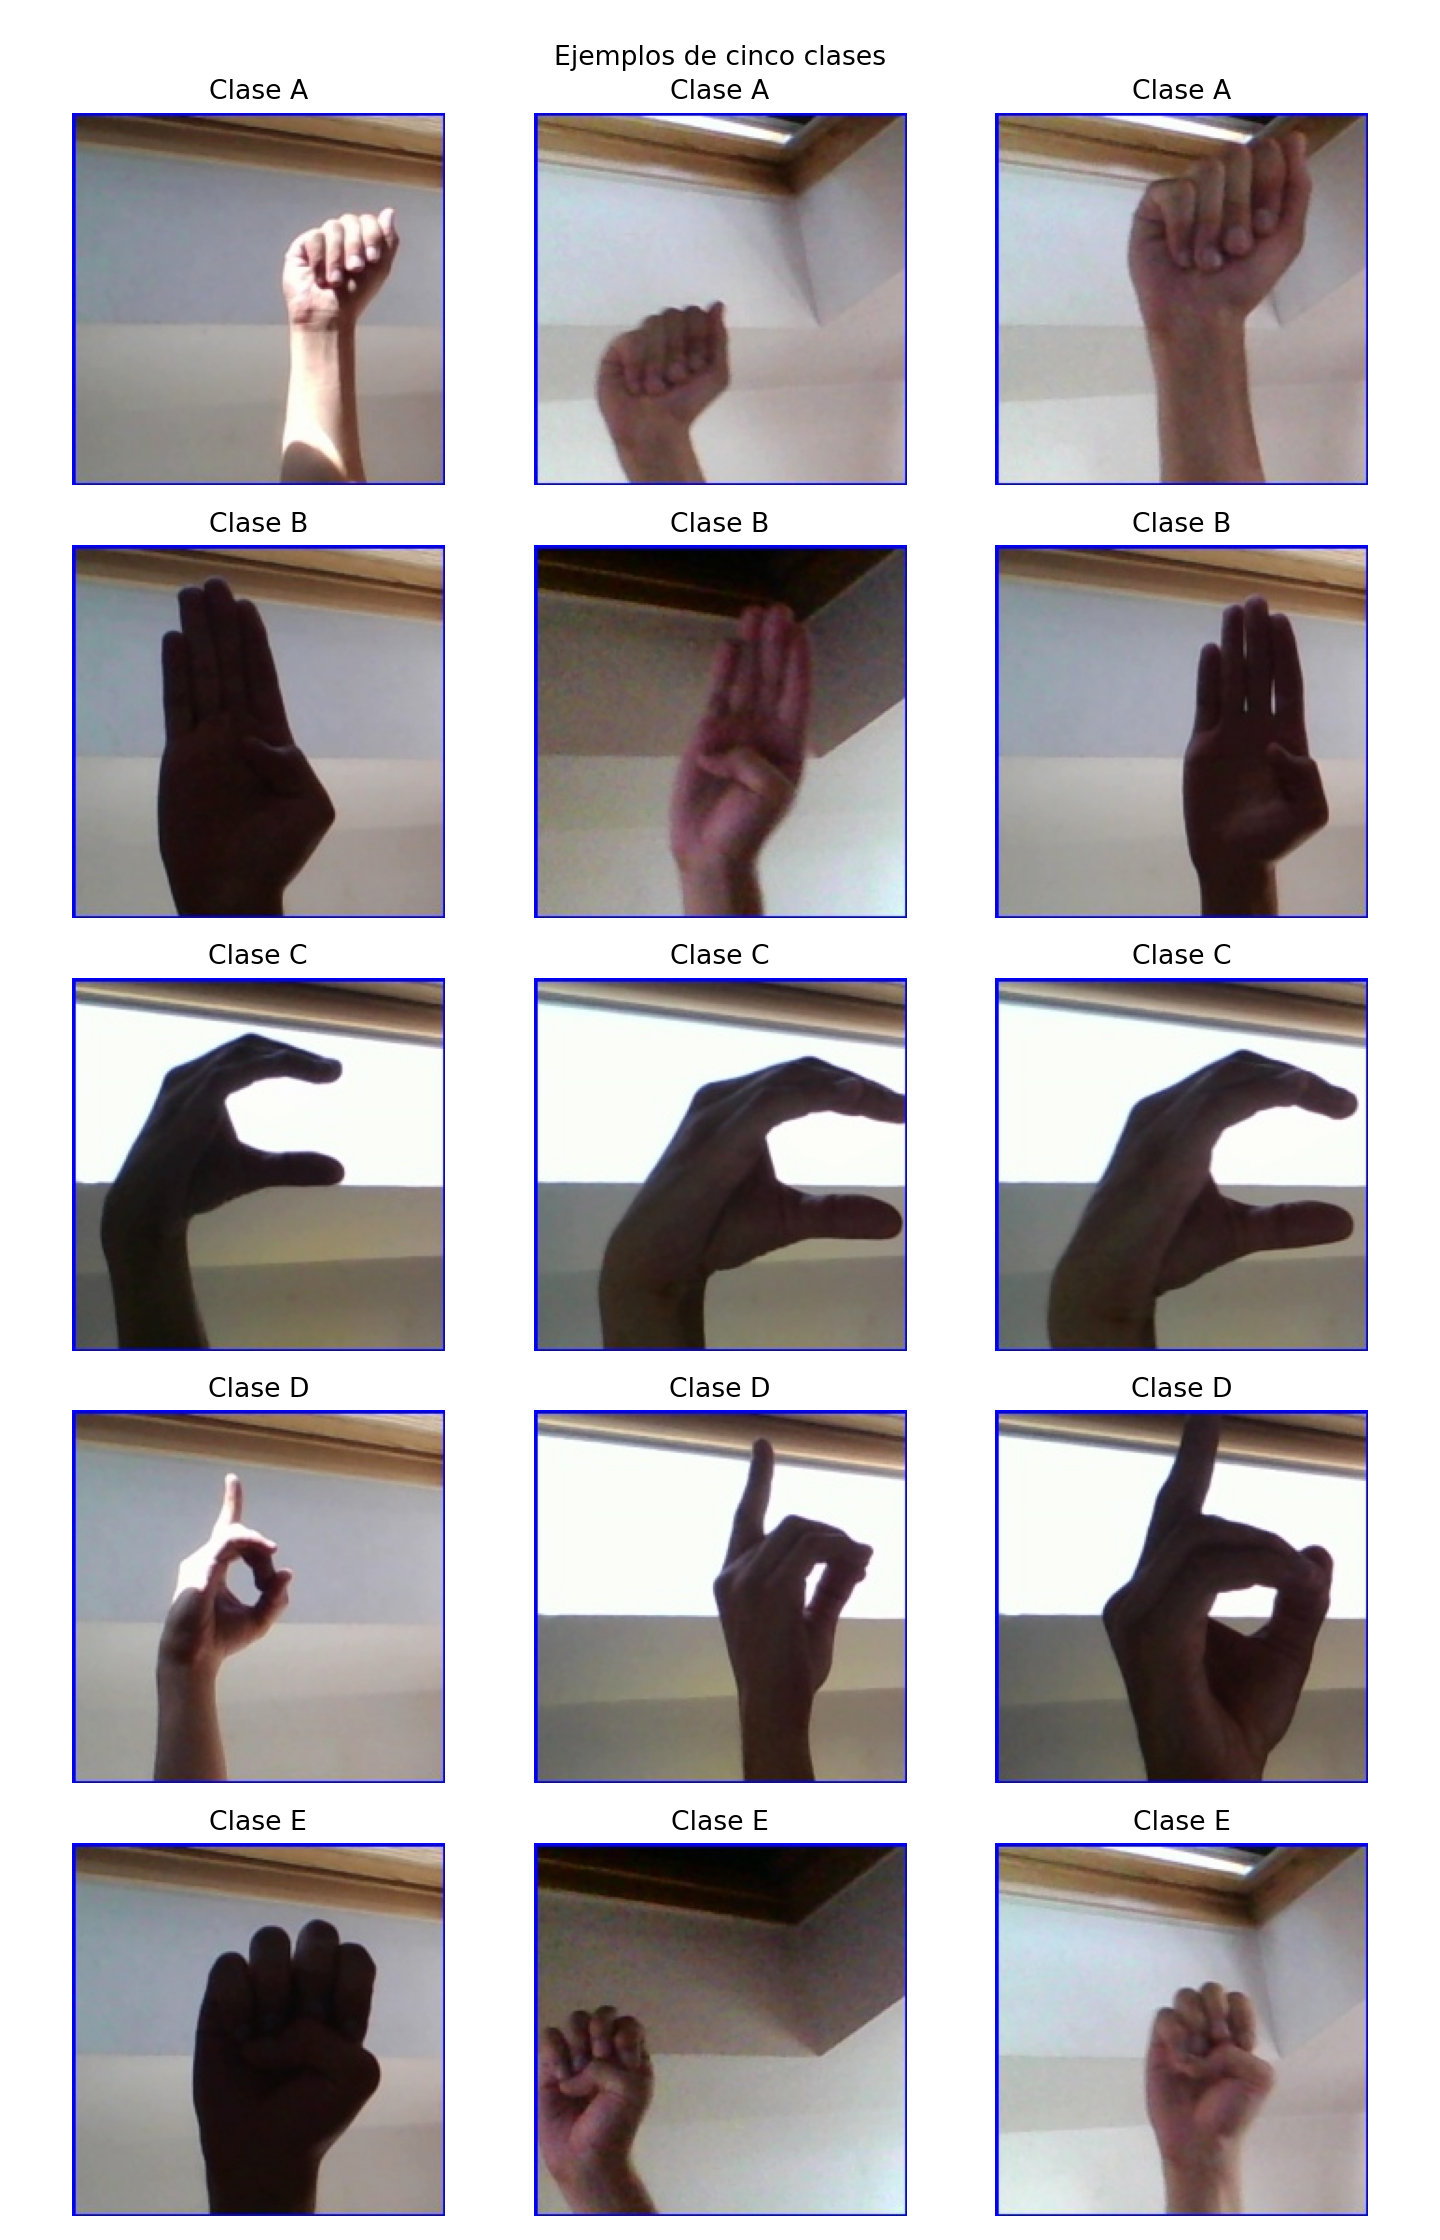

In [5]:
display(
    NotebookImage(
        filename=str(
            project_root
            / "data"
            / "processed"
            / "figures"
            / "sample_classes.png"
        )
    )
)

## Variabilidad dentro de una clase

La siguiente figura contiene varias imágenes de una misma clase.

La forma principal de la seña se conserva, pero pueden existir cambios leves en el encuadre y en las condiciones de la fotografía.

Esta variabilidad es importante porque el modelo no debe memorizar una sola imagen.

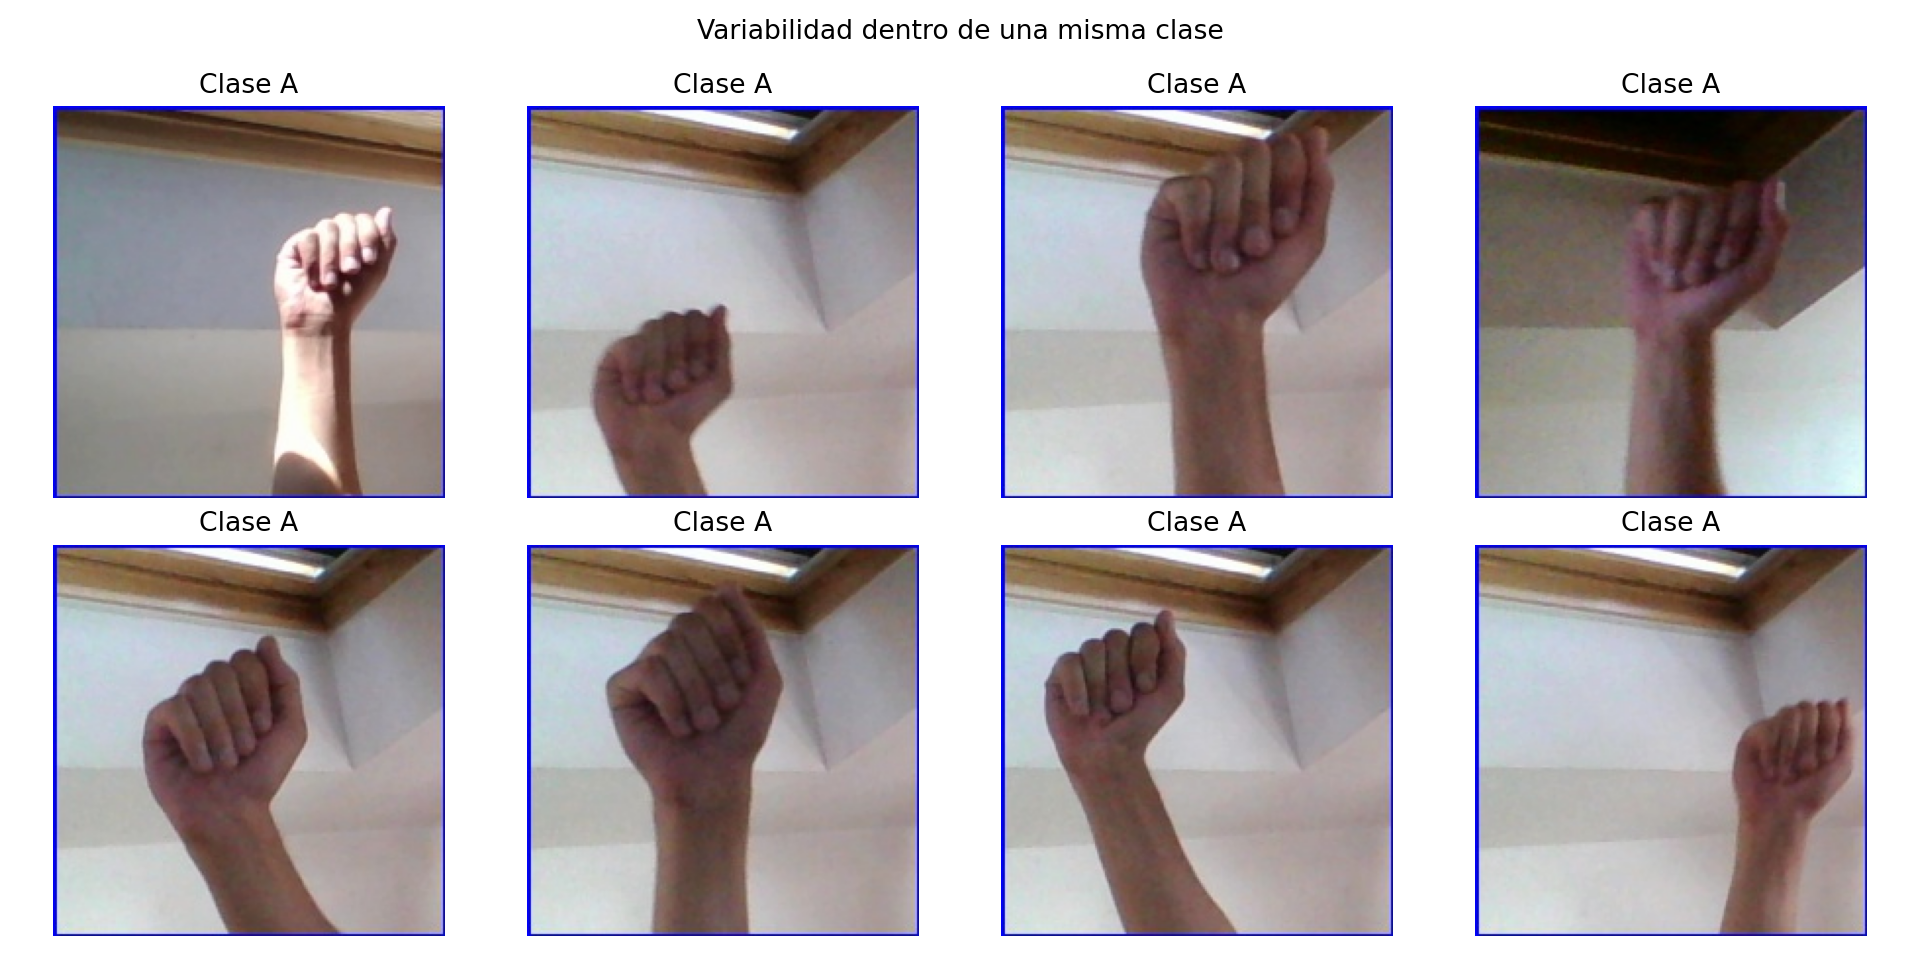

In [6]:
display(
    NotebookImage(
        filename=str(
            project_root
            / "data"
            / "processed"
            / "figures"
            / "same_class_variability.png"
        )
    )
)

## Clases visualmente similares

Las clases M, N y S tienen posiciones parecidas de los dedos.

Las clases U, V y R también comparten una forma general similar.

Estas clases pueden aparecer con frecuencia en la matriz de confusión.

El modelo necesitará aprender detalles pequeños en la posición y cruce de los dedos.

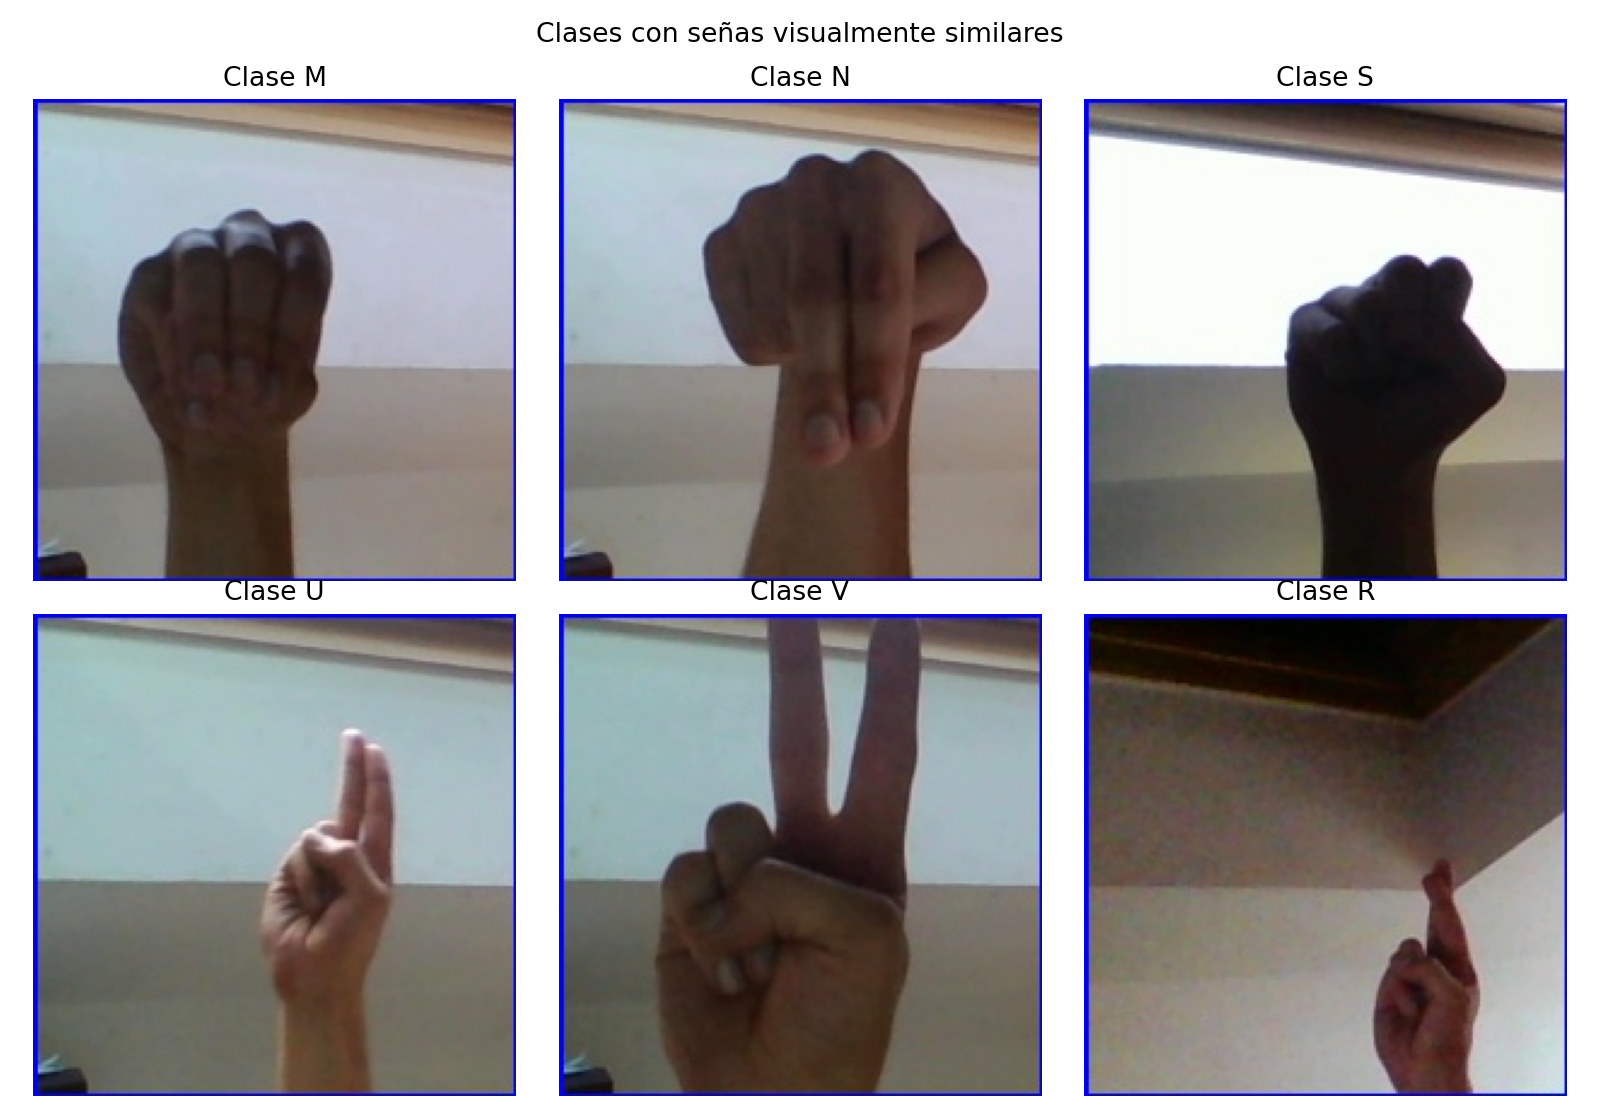

In [7]:
display(
    NotebookImage(
        filename=str(
            project_root
            / "data"
            / "processed"
            / "figures"
            / "similar_signs_comparison.png"
        )
    )
)

## Propiedades de las imágenes

Se revisan la resolución, el formato y el modo de color.

El objetivo es confirmar que las imágenes tienen una estructura compatible antes de entrenar.

,class_name,file_name,width,height,format,color_mode
0,A,A656.jpg,200,200,JPEG,RGB
1,A,A1409.jpg,200,200,JPEG,RGB
2,A,A1090.jpg,200,200,JPEG,RGB
3,A,A2011.jpg,200,200,JPEG,RGB
4,A,A1901.jpg,200,200,JPEG,RGB


,width,height,format,color_mode,count
0,200,200,JPEG,RGB,1450


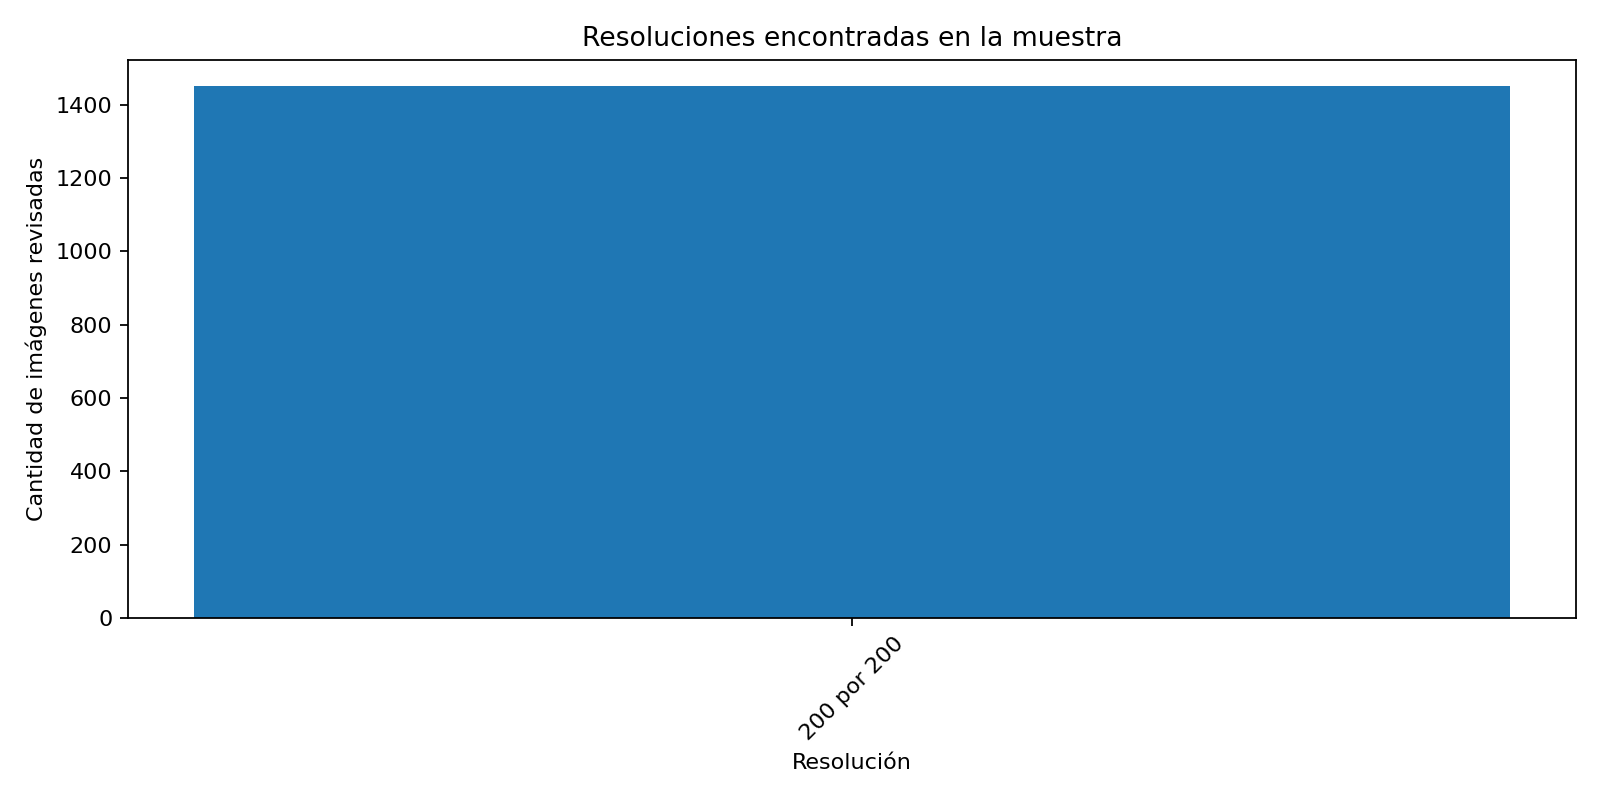

In [8]:
properties_path = (
    project_root
    / "data"
    / "processed"
    / "reports"
    / "image_properties_sample.csv"
)
properties = pd.read_csv(properties_path)

display(properties.head())
display(properties[["width", "height", "format", "color_mode"]].value_counts().reset_index(name="count"))

display(
    NotebookImage(
        filename=str(
            project_root
            / "data"
            / "processed"
            / "figures"
            / "image_properties.png"
        )
    )
)

## Preprocesamiento

Se seleccionarán como máximo 600 imágenes por clase.

La selección se hará con una semilla de 42 para poder repetir el proceso.

Las imágenes se dividirán de la siguiente forma.

- 70 por ciento para entrenamiento
- 15 por ciento para validación
- 15 por ciento para prueba

Todas las imágenes se convertirán a RGB.

La resolución se reducirá a 64 por 64 píxeles.

Los valores de los píxeles se dividirán entre 255 durante la carga.

In [9]:
from src.preprocess_images import run_preprocessing

preprocessing_summary = run_preprocessing(
    images_per_class=600,
    image_size=64,
    export_images=False,
)

preprocessing_summary

El plan de preprocesamiento terminó.
Imágenes seleccionadas: 17400
Resumen guardado en: C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\reports\preprocessing_summary.json


{'manifest_path': 'C:\\Users\\ninan\\OneDrive\\Documentos\\Escritorio\\UVG\\VIII SEMESTRE\\Data Science\\Data_Science\\data\\processed\\splits\\split_manifest.csv',
 'total_selected_images': 17400,
 'train_images': 12180,
 'validation_images': 2610,
 'test_images': 2610,
 'images_per_class_requested': 600,
 'image_size': 64,
 'color_mode': 'RGB',
 'normalization': 'Valores divididos entre 255 durante la carga',
 'random_seed': 42,
 'train_ratio': 0.7,
 'validation_ratio': 0.15,
 'test_ratio': 0.15,
 'preview_path': 'C:\\Users\\ninan\\OneDrive\\Documentos\\Escritorio\\UVG\\VIII SEMESTRE\\Data Science\\Data_Science\\data\\processed\\figures\\preprocessing_preview.png',
 'exported_images_directory': None}

## División creada

La división se realiza dentro de cada clase.

Esto ayuda a mantener una cantidad similar de cada seña en entrenamiento, validación y prueba.

,Conjunto,Cantidad
0,Entrenamiento,12180
1,Validación,2610
2,Prueba,2610


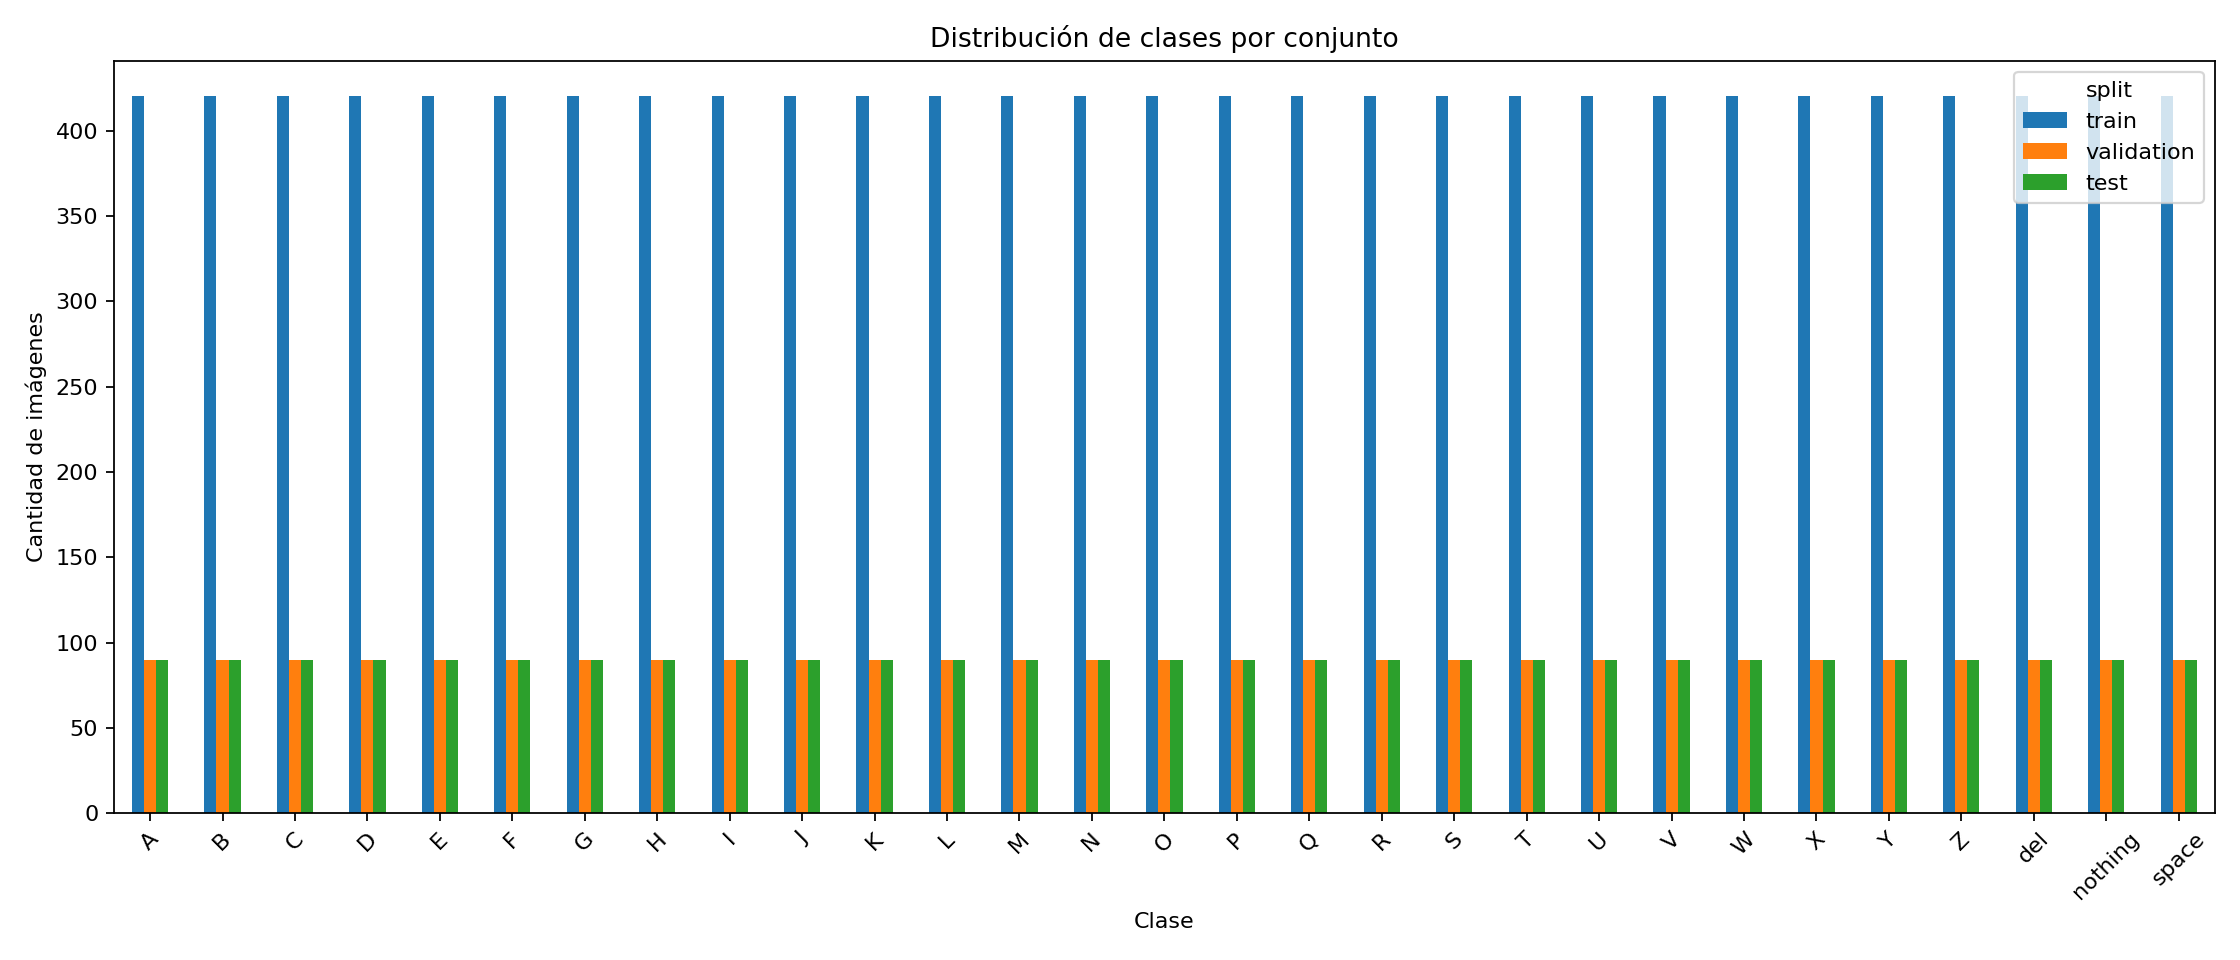

In [10]:
split_summary = pd.DataFrame(
    {
        "Conjunto": ["Entrenamiento", "Validación", "Prueba"],
        "Cantidad": [
            preprocessing_summary["train_images"],
            preprocessing_summary["validation_images"],
            preprocessing_summary["test_images"],
        ],
    }
)

display(split_summary)

display(
    NotebookImage(
        filename=str(
            project_root
            / "data"
            / "processed"
            / "figures"
            / "split_distribution.png"
        )
    )
)

## Vista previa del preprocesamiento

La figura compara imágenes originales con imágenes reducidas.

La reducción disminuye el uso de memoria y el tiempo de entrenamiento.

La forma general de la mano debe seguir siendo visible después del cambio.

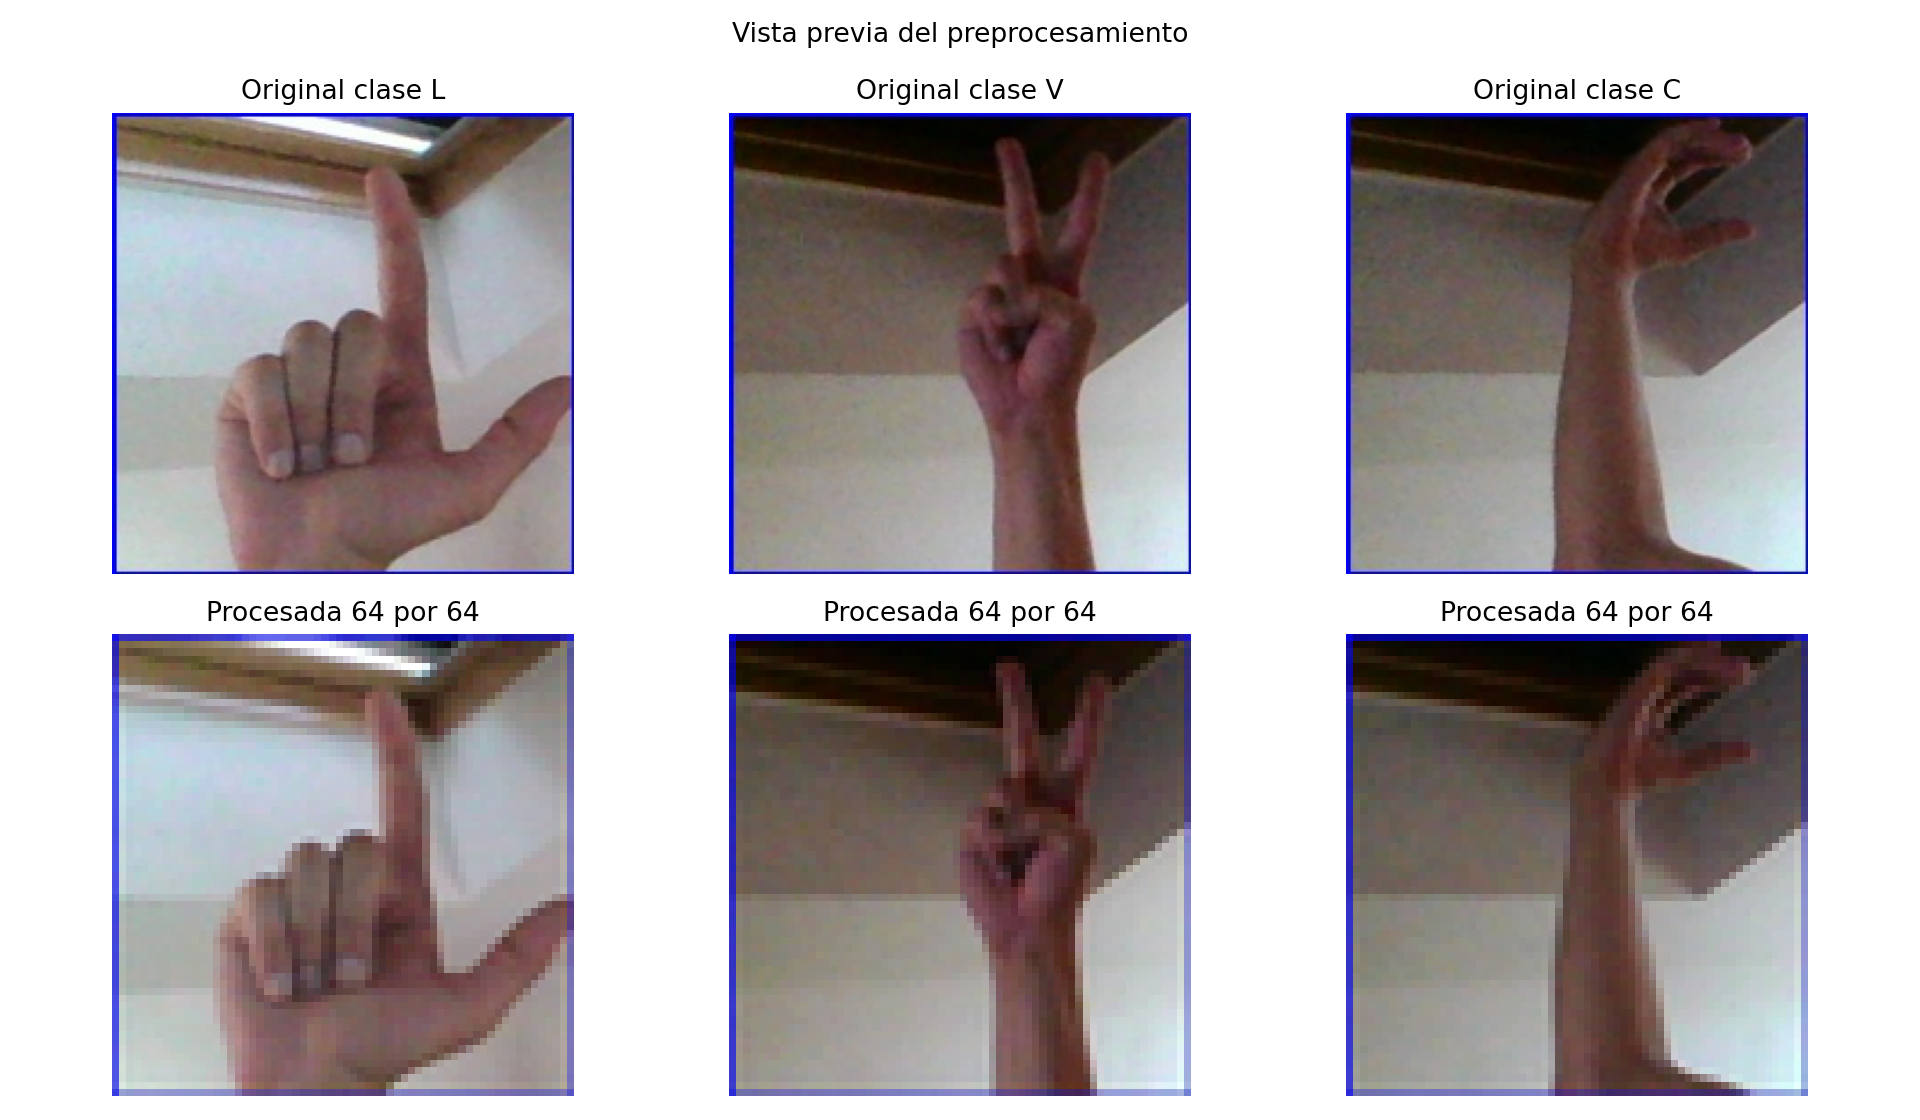

In [11]:
display(
    NotebookImage(
        filename=str(
            project_root
            / "data"
            / "processed"
            / "figures"
            / "preprocessing_preview.png"
        )
    )
)

## Aumento de datos

El aumento de datos se aplicará solamente al conjunto de entrenamiento.

Se probarán rotaciones pequeñas, desplazamientos pequeños, zoom moderado y cambios leves de brillo y contraste.

No se usará flip horizontal en la primera prueba.

Cambiar el lado de la mano puede producir una imagen que no representa la misma seña.

Tampoco se usarán recortes fuertes o deformaciones que oculten los dedos.

## Selección de modelos

### CNN base

La primera CNN tendrá pocas capas convolucionales.

Servirá como resultado inicial para medir la dificultad del problema.

### CNN mejorada

La segunda CNN tendrá más filtros, normalización por lotes, dropout y reducción global.

Se probarán diferentes tasas de aprendizaje, tamaños de lote y cantidades de filtros.

### Red neuronal fully connected

Este modelo recibirá la imagen como una lista de valores.

Se usará para comparar una red simple contra las CNN.

Puede perder información espacial porque no trabaja directamente con la posición de los píxeles.

### HOG y SVM

HOG permitirá extraer bordes y direcciones.

SVM clasificará esas características.

La selección tiene sentido porque la forma de la mano y la dirección de los dedos son importantes para reconocer las señas.

## Métricas para comparar modelos

Se usarán las siguientes métricas.

- Accuracy
- Precision macro
- Recall macro
- F1 macro
- Matriz de confusión
- Tiempo de entrenamiento

Las métricas macro darán el mismo peso a todas las clases.

La matriz de confusión ayudará a identificar las letras que el modelo confunde.

## Plan de procesamiento

1. Revisar la estructura del dataset

2. Contar las imágenes de cada clase

3. Mostrar ejemplos y variabilidad

4. Crear una submuestra balanceada

5. Dividir los datos

6. Convertir las imágenes a RGB

7. Reducir la resolución

8. Normalizar los valores

9. Entrenar los modelos sin aumento de datos

10. Entrenar nuevamente con aumento de datos

11. Comparar resultados

12. Elegir el mejor modelo

13. Probar el modelo con fotografías propias

## Conclusiones

El análisis exploratorio permite conocer la cantidad de clases, la distribución y las propiedades de las imágenes.

La división propuesta evita depender del pequeño conjunto oficial de prueba.

La reducción a 64 por 64 píxeles permitirá trabajar con menos memoria y menor tiempo de entrenamiento.

Las clases visualmente similares serán un punto importante durante la evaluación.

Se seleccionaron dos CNN, una red fully connected y un modelo HOG con SVM para comparar diferentes formas de resolver el problema.

## Repositorio
https://github.com/Ninaswiftie09/Data_Science/tree/Laboratorio3 

# Entrega final

A partir de este punto se continúa con el entrenamiento, ajuste y comparación de los modelos.

Se mantienen los datos y el preprocesamiento definidos en el avance.


## Modelos que se van a entrenar

Se entrenarán dos tipos de CNN.

También se entrenará una red fully connected y un modelo HOG con SVM.

Cada familia tendrá más de una configuración para comparar parámetros y elegir la mejor con el conjunto de validación.

Después se evaluará la mejor configuración de cada familia con el conjunto de prueba.


## Instalación de librerías 



In [ ]:
import tensorflow as tf
import sklearn
import skimage

print("TensorFlow:", tf.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Scikit-image:", skimage.__version__)
print("Dispositivos disponibles:", tf.config.list_physical_devices())


## Ajuste de parámetros

Para las CNN se comparan diferentes cantidades de filtros, dropout y tasa de aprendizaje.

Para la red fully connected se comparan diferentes tamaños de capas densas, dropout y tasa de aprendizaje.

Para SVM se comparan diferentes valores de C.

La selección de configuración se hace con validación y el conjunto de prueba se usa después para medir el resultado final.


In [ ]:
from src.model_training import run_all_training

training_output = run_all_training(
    tuning_epochs=3,
    augmented_epochs=5,
    batch_size=64,
    svm_augmented_per_class=120,
)

training_output["results"]


## Resultados del ajuste de parámetros

La siguiente tabla muestra el resultado de las configuraciones probadas antes de elegir el mejor modelo de cada familia.


In [ ]:
tuning_results = pd.read_csv(
    project_root
    / "data"
    / "processed"
    / "reports"
    / "model_tuning_results.csv"
)

columns_to_show = [
    "family",
    "model_name",
    "training_time_seconds",
    "validation_accuracy",
    "validation_precision_macro",
    "validation_recall_macro",
    "validation_f1_macro",
    "parameters",
]

display(
    tuning_results[columns_to_show]
    .sort_values(["family", "validation_accuracy"], ascending=[True, False])
    .reset_index(drop=True)
)


In [ ]:
from IPython.display import Markdown

best_by_family = (
    tuning_results
    .sort_values(["validation_accuracy", "validation_f1_macro"], ascending=False)
    .groupby("family", as_index=False)
    .first()
)

lines = ["### Mejores configuraciones encontradas", ""]
for row in best_by_family.itertuples():
    lines.append(
        f"- {row.family}: {row.model_name} con accuracy de validación de {row.validation_accuracy:.4f}"
    )

display(Markdown("\n".join(lines)))


## Comparación final de modelos

La tabla siguiente usa el conjunto de prueba.

Se incluyen las mejores configuraciones sin aumento de datos y las versiones entrenadas con aumento de datos.

Las métricas macro dan el mismo peso a todas las clases.


In [ ]:
all_results = pd.read_csv(
    project_root
    / "data"
    / "processed"
    / "reports"
    / "all_model_results.csv"
)

result_columns = [
    "family",
    "model_name",
    "augmentation",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "training_time_seconds",
]

display(
    all_results[result_columns]
    .sort_values(["accuracy", "f1_macro"], ascending=False)
    .reset_index(drop=True)
)


In [ ]:
best_model_path = (
    project_root
    / "data"
    / "processed"
    / "reports"
    / "best_model.json"
)

with open(best_model_path, "r", encoding="utf-8") as file:
    best_model = json.load(file)

best_text = (
    "### Mejor modelo\n\n"
    f"El mejor modelo fue {best_model['model_name']}.\n\n"
    f"Obtuvo un accuracy de {best_model['accuracy']:.4f} y un F1 macro de {best_model['f1_macro']:.4f} en el conjunto de prueba.\n\n"
    f"La versión seleccionada {'usa' if best_model['augmentation'] else 'no usa'} aumento de datos."
)

display(Markdown(best_text))


## Matriz de confusión del mejor modelo

La matriz de confusión permite observar en qué clases se concentran los errores.

Es especialmente útil para revisar las letras que tienen posiciones de dedos parecidas.


In [ ]:
confusion_path = project_root / best_model["confusion_matrix_path"]

display(
    NotebookImage(
        filename=str(confusion_path)
    )
)


## Comparación del aumento de datos

El aumento de datos usa rotaciones pequeñas, desplazamientos pequeños, zoom y cambios leves de brillo y contraste.

No se usa flip horizontal.

En lenguaje de señas el lado y la orientación de la mano son parte de la información visual. Un flip horizontal puede crear una imagen que no representa exactamente la misma seña.

Tampoco se usan rotaciones grandes o recortes fuertes porque pueden cambiar la posición de los dedos o esconder parte de la mano.


In [ ]:
augmentation_comparison = all_results.copy()
augmentation_comparison["version"] = augmentation_comparison["augmentation"].map(
    {False: "Sin aumento", True: "Con aumento"}
)

augmentation_table = augmentation_comparison.pivot_table(
    index="family",
    columns="version",
    values=["accuracy", "f1_macro"],
    aggfunc="max",
)

display(augmentation_table)


In [ ]:
lines = ["### Efecto del aumento de datos", ""]

for family in sorted(all_results["family"].unique()):
    family_results = all_results[all_results["family"] == family]
    baseline = family_results[family_results["augmentation"] == False]
    augmented = family_results[family_results["augmentation"] == True]

    if baseline.empty or augmented.empty:
        continue

    baseline_accuracy = float(baseline.iloc[0]["accuracy"])
    augmented_accuracy = float(augmented.iloc[0]["accuracy"])
    difference = augmented_accuracy - baseline_accuracy

    if difference > 0:
        effect = "mejoró"
    elif difference < 0:
        effect = "bajó"
    else:
        effect = "se mantuvo"

    lines.append(
        f"- {family}: el accuracy {effect} de {baseline_accuracy:.4f} a {augmented_accuracy:.4f}."
    )

display(Markdown("\n".join(lines)))


## Modelo HOG con SVM

Se seleccionó HOG con SVM como algoritmo adicional.

HOG representa bordes y direcciones de la imagen. Esto ayuda a describir la forma de la mano y la posición de los dedos.

SVM usa estas características para separar las clases.

Se probaron varios valores de C y se seleccionó el mejor resultado usando validación.


In [ ]:
svm_tuning = tuning_results[tuning_results["family"] == "hog_svm"].copy()

display(
    svm_tuning[
        [
            "model_name",
            "validation_accuracy",
            "validation_precision_macro",
            "validation_recall_macro",
            "validation_f1_macro",
            "training_time_seconds",
            "parameters",
        ]
    ].sort_values("validation_accuracy", ascending=False)
)


## Pruebas con fotos propias



In [ ]:
from src.own_images import evaluate_own_images

own_results = evaluate_own_images()

if own_results is not None:
    display(own_results["member_summary"])
    display(own_results["predictions"])
else:
    display(
        Markdown(
            "No se encontraron imágenes propias para evaluar."
        )
    )


In [ ]:
if own_results is not None:
    own_accuracy = own_results["overall_accuracy"]
    own_text = (
        "### Resultado con fotografías propias\n\n"
        f"Se evaluaron {len(own_results['predictions'])} fotografías propias.\n\n"
        f"El accuracy general con estas imágenes fue de {own_accuracy:.4f}.\n\n"
        "Este resultado permite comparar el desempeño dentro del dataset contra imágenes tomadas en condiciones diferentes."
    )
    display(Markdown(own_text))


## Accesibilidad y sesgo

El dataset es útil para crear un primer prototipo, pero no representa todas las condiciones que tendría una aplicación real.

El tono de piel puede cambiar el contraste entre la mano y el fondo. Si algunos tonos aparecen poco en el entrenamiento, el modelo puede funcionar peor para esas personas.

El ángulo de la cámara también es importante. Una seña puede verse diferente cuando la cámara está más arriba, más abajo o inclinada.

La iluminación puede producir sombras o zonas muy claras. Esto puede esconder detalles de los dedos que son importantes para diferenciar letras parecidas.

El tamaño de la mano y la distancia a la cámara también cambian la cantidad de espacio que ocupa la mano dentro de la imagen.

Para acercar el prototipo a un uso real se necesita recolectar un conjunto más variado. Se deberían incluir personas con diferentes tonos de piel, tamaños de mano, fondos, cámaras, distancias e iluminación.

También sería importante probar el sistema con personas que usan ASL y medir el desempeño en condiciones reales antes de usarlo como una herramienta de accesibilidad.


In [ ]:
best_result = all_results.sort_values(
    ["accuracy", "f1_macro"],
    ascending=False,
).iloc[0]

conclusion = (
    "## Conclusiones finales\n\n"
    "Se compararon dos tipos de CNN, una red fully connected y un modelo HOG con SVM.\n\n"
    "También se probaron diferentes configuraciones y se entrenaron versiones con aumento de datos.\n\n"
    f"El mejor resultado en el conjunto de prueba fue {best_result['model_name']} con un accuracy de {best_result['accuracy']:.4f} y un F1 macro de {best_result['f1_macro']:.4f}.\n\n"
    "La comparación muestra cuál enfoque se adapta mejor a las imágenes del alfabeto ASL usadas en este laboratorio.\n\n"
    "La matriz de confusión permite revisar las clases que todavía presentan errores y las pruebas con fotografías propias permiten medir qué tan bien se generaliza el modelo fuera del dataset.\n\n"
    "El prototipo todavía necesita datos más variados y pruebas con personas y condiciones diferentes antes de considerarse listo para un caso de uso real de accesibilidad."
)

display(Markdown(conclusion))
